<a href="https://colab.research.google.com/github/vishalnagar0157/AI-Chatbot-for-Student-Support-Services.ipynb/blob/main/AI_Chatbot_for_Student_Support_Services.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **🎓 AI Chatbot for Student Support Services**
What this project does
The chatbot will identify the intent behind a student's question.
| Student question                   | Predicted intent    |
| ---------------------------------- | ------------------- |
| “How do I pay my college fees?”    | `fees`              |
| “When does the semester start?”    | `academic_calendar` |
| “How can I get a scholarship?”     | `scholarship`       |
| “Where is the library?”            | `library`           |
| “How do I apply for hostel?”       | `hostel`            |
| “How can I get my exam timetable?” | `examination`       |



# 🎓AI Chatbot for Student Support Services

## **📌Project Overview**

*   An AI-based chatbot designed to answer common student queries
*   Uses Natural Language Processing (NLP) and Machine Learning for intent classification.

*  Provides automated responses for areas such as admissions, fees, scholarships, examinations, library, hostel, and results.
*   Developed using Python and Google Colab.



  



# 🎯**Project Objective**


*   To automate responses to common student queries.
*   To provide quick and accessible student support.
*   To classify student questions into relevant categories.
*   To reduce repetitive workload for support staff.
*   To improve the overall student-support experience.



#🌐 **Technologies Used**


*    Programming Language: Python
*  Platform: Google Colab

*   Libraries: Pandas, NumPy, Matplotlib, Seaborn
*   Machine Learning: Scikit-learn

*    NLP: Text preprocessing and TF-IDF
*   Models: Logistic Regression, Multinomial Naive Bayes, Random Forest

*  Model Storage: Pickle








# **1. Import Libraries**

Here we import all libraries required for the project.

pandas → dataset handling

numpy → numerical operations

matplotlib → visualization

seaborn → charts

re → text preprocessing

pickle → saving the trained chatbot model

TfidfVectorizer → converts text into numerical TF-IDF features

LogisticRegression → classification model

MultinomialNB → Naive Bayes classification

RandomForestClassifier → ensemble classification

classification_report → evaluates precision, recall and F1-score

In [7]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import string
import random
import warnings
import os
import pickle

warnings.filterwarnings("ignore")

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully!")

Libraries imported successfully!


# **2 — Create the Student Support Dataset**
Student questions

Corresponding intent/category

Chatbot response






#🗃️ **Dataset**
Dataset covers common student-support topics.

Main categories include:


*  Admission
*  Fees
*   Scholarship
*    Examination
*    Results
*   Library
*  Hostel
*   Transportation
*    Academic Calenda
*  Certificates
*    Attendance
*  Technical Support
*  Contact Information
*   General Information
*   Greeting and Goodbye



In [8]:

data = [

# ------------------------------------------------
# GREETING
# ------------------------------------------------

("hello", "greeting"),
("hi", "greeting"),
("hey", "greeting"),
("good morning", "greeting"),
("good afternoon", "greeting"),
("good evening", "greeting"),
("hello chatbot", "greeting"),
("hi there", "greeting"),
("hey there", "greeting"),
("how are you", "greeting"),

# ------------------------------------------------
# ADMISSIONS
# ------------------------------------------------

("how can I apply for admission", "admission"),
("how do I get admission", "admission"),
("what is the admission process", "admission"),
("where can I apply for college admission", "admission"),
("what documents are required for admission", "admission"),
("when does admission start", "admission"),
("when is the admission deadline", "admission"),
("can I apply online for admission", "admission"),
("tell me about the admission procedure", "admission"),
("how can a new student apply", "admission"),

# ------------------------------------------------
# FEES
# ------------------------------------------------

("how do I pay my fees", "fees"),
("where can I pay college fees", "fees"),
("what is the fee structure", "fees"),
("how much are the semester fees", "fees"),
("when is the fee payment deadline", "fees"),
("can I pay fees online", "fees"),
("how can I download my fee receipt", "fees"),
("I need information about tuition fees", "fees"),
("what are the college fees", "fees"),
("where can I get my payment receipt", "fees"),

# ------------------------------------------------
# SCHOLARSHIP
# ------------------------------------------------

("how can I apply for scholarship", "scholarship"),
("what scholarships are available", "scholarship"),
("tell me about scholarships", "scholarship"),
("who is eligible for scholarship", "scholarship"),
("what are the scholarship requirements", "scholarship"),
("when is the scholarship deadline", "scholarship"),
("how do I submit scholarship documents", "scholarship"),
("can I get a scholarship", "scholarship"),
("where can I apply for scholarship", "scholarship"),
("is there financial aid for students", "scholarship"),

# ------------------------------------------------
# EXAMINATION
# ------------------------------------------------

("when are the exams", "examination"),
("when is my exam", "examination"),
("where can I find the exam timetable", "examination"),
("how can I download exam schedule", "examination"),
("tell me about examination dates", "examination"),
("where is the examination schedule", "examination"),
("when will semester exams begin", "examination"),
("how do I get exam information", "examination"),
("what is the exam date", "examination"),
("where can I check my exam timetable", "examination"),

# ------------------------------------------------
# RESULTS
# ------------------------------------------------

("when will results be declared", "results"),
("where can I check my results", "results"),
("how do I see my exam results", "results"),
("when are semester results released", "results"),
("how can I download my result", "results"),
("where is the result portal", "results"),
("my results are not showing", "results"),
("how do I check marks", "results"),
("when will semester results come", "results"),
("tell me about result publication", "results"),

# ------------------------------------------------
# LIBRARY
# ------------------------------------------------

("where is the library", "library"),
("what are the library timings", "library"),
("when does the library open", "library"),
("when does the library close", "library"),
("how can I issue a book", "library"),
("how many books can I borrow", "library"),
("how do I return a library book", "library"),
("can I renew a library book", "library"),
("what are the library rules", "library"),
("tell me about library services", "library"),

# ------------------------------------------------
# HOSTEL
# ------------------------------------------------

("how can I apply for hostel", "hostel"),
("is hostel available", "hostel"),
("what is the hostel fee", "hostel"),
("how do I get a hostel room", "hostel"),
("what are the hostel rules", "hostel"),
("when is hostel registration", "hostel"),
("are hostel facilities available", "hostel"),
("tell me about student accommodation", "hostel"),
("where can I apply for hostel", "hostel"),
("what documents are needed for hostel", "hostel"),

# ------------------------------------------------
# TRANSPORT
# ------------------------------------------------

("does the college provide bus service", "transport"),
("what are the bus timings", "transport"),
("where can I find bus routes", "transport"),
("how can I apply for transport", "transport"),
("is college transportation available", "transport"),
("what is the transport fee", "transport"),
("where does the college bus go", "transport"),
("how can I get a bus pass", "transport"),
("when does the college bus leave", "transport"),
("tell me about transportation facilities", "transport"),

# ------------------------------------------------
# ACADEMIC CALENDAR
# ------------------------------------------------

("when does the semester start", "academic_calendar"),
("when does the semester end", "academic_calendar"),
("where can I find the academic calendar", "academic_calendar"),
("when are holidays", "academic_calendar"),
("what is the academic schedule", "academic_calendar"),
("when does the new session begin", "academic_calendar"),
("tell me about the college calendar", "academic_calendar"),
("when is the next semester", "academic_calendar"),
("what are the semester dates", "academic_calendar"),
("where can I download academic calendar", "academic_calendar"),

# ------------------------------------------------
# CERTIFICATE
# ------------------------------------------------

("how can I get a bonafide certificate", "certificate"),
("how do I apply for a certificate", "certificate"),
("where can I get a student certificate", "certificate"),
("how can I request a bonafide certificate", "certificate"),
("I need a college certificate", "certificate"),
("where can I apply for documents", "certificate"),
("how long does certificate processing take", "certificate"),
("what documents are required for certificate", "certificate"),
("how do I get a migration certificate", "certificate"),
("how can I request a character certificate", "certificate"),

# ------------------------------------------------
# ATTENDANCE
# ------------------------------------------------

("what is the attendance requirement", "attendance"),
("how much attendance is required", "attendance"),
("where can I check my attendance", "attendance"),
("how do I see attendance percentage", "attendance"),
("what happens if my attendance is low", "attendance"),
("can I check attendance online", "attendance"),
("tell me about attendance rules", "attendance"),
("what is minimum attendance", "attendance"),
("how can I improve my attendance", "attendance"),
("where is attendance information", "attendance"),

# ------------------------------------------------
# TECHNICAL SUPPORT
# ------------------------------------------------

("I cannot login to the student portal", "technical_support"),
("student portal is not working", "technical_support"),
("I forgot my password", "technical_support"),
("how do I reset my password", "technical_support"),
("I cannot access my account", "technical_support"),
("website is not working", "technical_support"),
("I am having login problems", "technical_support"),
("my student account is locked", "technical_support"),
("how can I get technical help", "technical_support"),
("portal login problem", "technical_support"),

# ------------------------------------------------
# CONTACT
# ------------------------------------------------

("how can I contact the college", "contact"),
("what is the college phone number", "contact"),
("what is the administration contact", "contact"),
("how can I contact student support", "contact"),
("where is the administration office", "contact"),
("how do I contact the registrar", "contact"),
("who should I contact for help", "contact"),
("where can I get contact information", "contact"),
("what is the support office number", "contact"),
("how can I reach the college office", "contact"),

# ------------------------------------------------
# GENERAL INFORMATION
# ------------------------------------------------

("tell me about the college", "general_information"),
("what services are available for students", "general_information"),
("what student services are available", "general_information"),
("tell me about student support", "general_information"),
("what facilities does the college provide", "general_information"),
("what facilities are available", "general_information"),
("tell me about campus services", "general_information"),
("what help can students get", "general_information"),
("what support is available", "general_information"),
("tell me about student facilities", "general_information"),

# ------------------------------------------------
# GOODBYE
# ------------------------------------------------

("bye", "goodbye"),
("goodbye", "goodbye"),
("see you later", "goodbye"),
("thank you bye", "goodbye"),
("I have to go", "goodbye"),
("talk to you later", "goodbye"),
("thanks goodbye", "goodbye"),
("see you", "goodbye"),
("exit", "goodbye"),
("quit", "goodbye")
]

df = pd.DataFrame(data, columns=["text", "intent"])

print("Dataset created successfully!")
print("Number of records:", len(df))
print("Number of intents:", df["intent"].nunique())

Dataset created successfully!
Number of records: 160
Number of intents: 16


# **3 — Display Dataset**

In [9]:
# ============================================
# CELL 3: DISPLAY DATASET
# ============================================

df.head(20)

,text,intent
0,hello,greeting
1,hi,greeting
2,hey,greeting
3,good morning,greeting
4,good afternoon,greeting
5,good evening,greeting
6,hello chatbot,greeting
7,hi there,greeting
8,hey there,greeting
9,how are you,greeting


# Explanation
This displays the first 20 student questions and their corresponding intents.

Our dataset has two important columns:

text    → student's question

intent  → category of question

## **4 — Dataset Information**


In [10]:
# ============================================
# CELL 4: DATASET INFORMATION
# ============================================

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape: (160, 2)

Column Names:
['text', 'intent']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160 entries, 0 to 159
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    160 non-null    object
 1   intent  160 non-null    object
dtypes: object(2)
memory usage: 2.6+ KB

Missing Values:
text      0
intent    0
dtype: int64

Duplicate Rows:
0


## **5 — Intent Distribution**

In [11]:
# ============================================
# CELL 5: INTENT DISTRIBUTION
# ============================================

intent_counts = df["intent"].value_counts()

print(intent_counts)

intent
greeting               10
admission              10
fees                   10
scholarship            10
examination            10
results                10
library                10
hostel                 10
transport              10
academic_calendar      10
certificate            10
attendance             10
technical_support      10
contact                10
general_information    10
goodbye                10
Name: count, dtype: int64


# **6 — Visualize Intent Distribution**

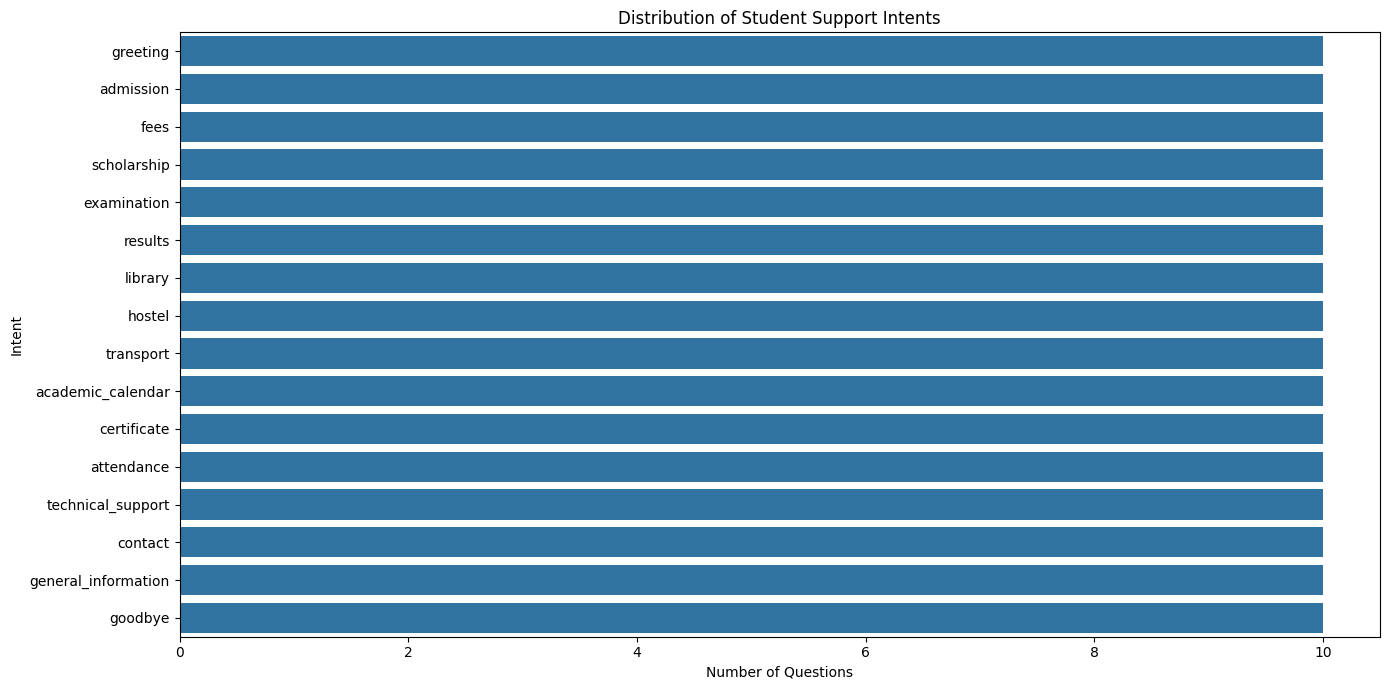

In [12]:
# ============================================
# CELL 6: VISUALIZATION
# ============================================

plt.figure(figsize=(14, 7))

sns.countplot(
    data=df,
    y="intent",
    order=df["intent"].value_counts().index
)

plt.title("Distribution of Student Support Intents")
plt.xlabel("Number of Questions")
plt.ylabel("Intent")

plt.tight_layout()
plt.show()

# Explanation
This graph shows how many training examples belong to each intent.

This is part of Exploratory Data Analysis (EDA).

## **7 — Text Preprocessing**
Now we clean the student questions.

In [13]:
# ============================================
# CELL 7: TEXT PREPROCESSING
# ============================================

def clean_text(text):
    """
    Clean text before machine learning.
    """

    # Convert text to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove punctuation
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text


df["clean_text"] = df["text"].apply(clean_text)

df.head(20)

,text,intent,clean_text
0,hello,greeting,hello
1,hi,greeting,hi
2,hey,greeting,hey
3,good morning,greeting,good morning
4,good afternoon,greeting,good afternoon
5,good evening,greeting,good evening
6,hello chatbot,greeting,hello chatbot
7,hi there,greeting,hi there
8,hey there,greeting,hey there
9,how are you,greeting,how are you


# Explanation
For example:

Original:
"How do I pay my College Fees?"

After preprocessing:
"how do i pay my college fees"

# **8 — Compare Original and Clean Text**

In [14]:
# ============================================
# CELL 8: ORIGINAL VS CLEAN TEXT
# ============================================

comparison_df = df[["text", "clean_text", "intent"]].head(15)

comparison_df

,text,clean_text,intent
0,hello,hello,greeting
1,hi,hi,greeting
2,hey,hey,greeting
3,good morning,good morning,greeting
4,good afternoon,good afternoon,greeting
5,good evening,good evening,greeting
6,hello chatbot,hello chatbot,greeting
7,hi there,hi there,greeting
8,hey there,hey there,greeting
9,how are you,how are you,greeting


## **9 — Separate Input and Target**

In [15]:
# ============================================
# CELL 9: INPUT AND TARGET
# ============================================

X = df["clean_text"]
y = df["intent"]

print("Input data:")
print(X.head())

print("\nTarget data:")
print(y.head())

Input data:
0             hello
1                hi
2               hey
3      good morning
4    good afternoon
Name: clean_text, dtype: object

Target data:
0    greeting
1    greeting
2    greeting
3    greeting
4    greeting
Name: intent, dtype: object


Explanation

Here:
X = student questions

y = intent/category

The model learns the relationship between the question and its intent.


## **10 — Train/Test Split**

In [16]:
# ============================================
# CELL 10: TRAIN TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 128
Testing samples: 32


Explanation

We use:

80% → training

20% → testing

random_state=42 makes the experiment reproducible, while stratify=y keeps the class distribution balanced between the splits.

## **11 — TF-IDF Feature Extraction**

In [17]:
# ============================================
# CELL 11: TF-IDF FEATURE EXTRACTION
# ============================================

tfidf = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (128, 421)
Testing TF-IDF shape: (32, 421)


## **12 — View TF-IDF Features**

In [18]:
# ============================================
# CELL 12: VIEW TF-IDF FEATURES
# ============================================

feature_names = tfidf.get_feature_names_out()

print("Total number of features:", len(feature_names))

print("\nFirst 50 features:")
print(feature_names[:50])

Total number of features: 421

First 50 features:
['about' 'about attendance' 'about library' 'about result'
 'about scholarships' 'about student' 'about the' 'about transportation'
 'about tuition' 'academic' 'academic calendar' 'academic schedule'
 'access' 'access my' 'accommodation' 'account' 'account is'
 'administration' 'administration office' 'admission'
 'admission procedure' 'admission start' 'afternoon' 'aid' 'aid for'
 'apply' 'apply for' 'apply online' 'are' 'are available' 'are hostel'
 'are needed' 'are not' 'are required' 'are semester' 'are the'
 'attendance' 'attendance information' 'attendance online'
 'attendance percentage' 'attendance requirement' 'attendance rules'
 'available' 'available for' 'begin' 'bonafide' 'bonafide certificate'
 'book' 'books' 'books can']


## **13 — Train Logistic Regression**

In [19]:
# ============================================
# CELL 13: LOGISTIC REGRESSION
# ============================================

logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

logistic_model.fit(
    X_train_tfidf,
    y_train
)

logistic_predictions = logistic_model.predict(
    X_test_tfidf
)

logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

print("Logistic Regression Accuracy:",
      round(logistic_accuracy * 100, 2), "%")

Logistic Regression Accuracy: 75.0 %


# Explanation

Logistic Regression is a classification algorithm that can work with sparse text features, making it a natural baseline for this type of NLP classification task.

## **14 — Train Naive Bayes**

In [20]:
# ============================================
# CELL 14: NAIVE BAYES
# ============================================

nb_model = MultinomialNB()

nb_model.fit(
    X_train_tfidf,
    y_train
)

nb_predictions = nb_model.predict(
    X_test_tfidf
)

nb_accuracy = accuracy_score(
    y_test,
    nb_predictions
)

print("Naive Bayes Accuracy:",
      round(nb_accuracy * 100, 2), "%")

Naive Bayes Accuracy: 65.62 %


## **15 — Train Random Forest**

In [21]:
# ============================================
# CELL 15: RANDOM FOREST
# ============================================

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_tfidf,
    y_train
)

rf_predictions = rf_model.predict(
    X_test_tfidf
)

rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

print("Random Forest Accuracy:",
      round(rf_accuracy * 100, 2), "%")

Random Forest Accuracy: 59.38 %


## **16 — Compare Models**

In [22]:
# ============================================
# CELL 16: MODEL COMPARISON
# ============================================

model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        nb_accuracy,
        rf_accuracy
    ]
})

model_results["Accuracy (%)"] = (
    model_results["Accuracy"] * 100
).round(2)

model_results

,Model,Accuracy,Accuracy (%)
0,Logistic Regression,0.75000,75.00
1,Naive Bayes,0.65625,65.62
2,Random Forest,0.59375,59.38


## **17 — Visualize Model Accuracy**

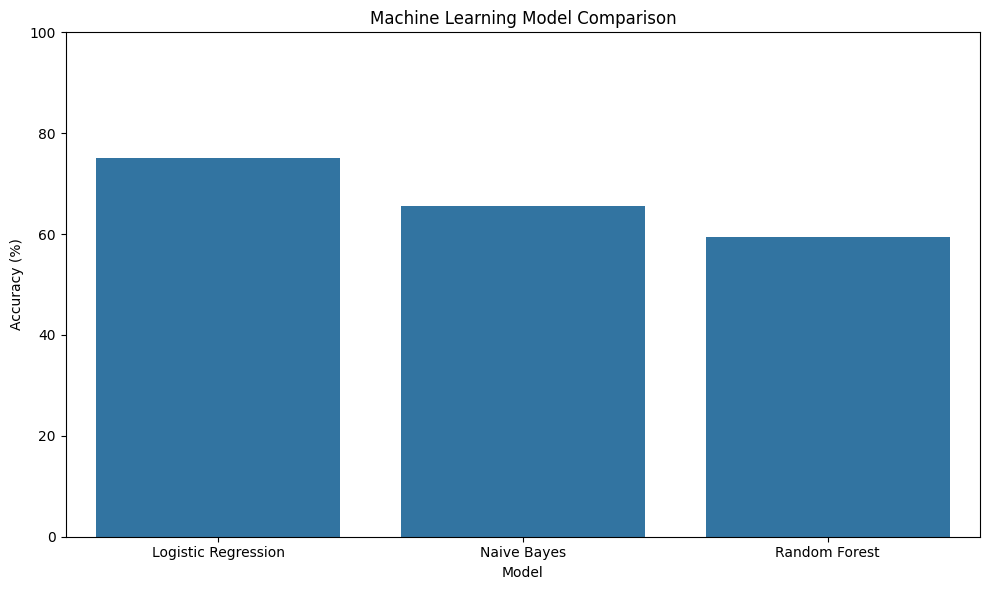

In [23]:
# ============================================
# CELL 17: MODEL ACCURACY VISUALIZATION
# ============================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=model_results,
    x="Model",
    y="Accuracy (%)"
)

plt.title("Machine Learning Model Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy (%)")

plt.ylim(0, 100)

plt.tight_layout()
plt.show()

## **18 — Automatically Select Best Model**

In [24]:
# ============================================
# CELL 18: SELECT BEST MODEL
# ============================================

models = {
    "Logistic Regression": logistic_model,
    "Naive Bayes": nb_model,
    "Random Forest": rf_model
}

accuracies = {
    "Logistic Regression": logistic_accuracy,
    "Naive Bayes": nb_accuracy,
    "Random Forest": rf_accuracy
}

best_model_name = max(
    accuracies,
    key=accuracies.get
)

best_model = models[best_model_name]

print("Best Model:", best_model_name)
print(
    "Best Accuracy:",
    round(accuracies[best_model_name] * 100, 2),
    "%"
)

Best Model: Logistic Regression
Best Accuracy: 75.0 %


# **19 — Classification Report**

In [25]:
# ============================================
# CELL 19: CLASSIFICATION REPORT
# ============================================

best_predictions = best_model.predict(
    X_test_tfidf
)

print(
    classification_report(
        y_test,
        best_predictions,
        zero_division=0
    )
)

                     precision    recall  f1-score   support

  academic_calendar       0.00      0.00      0.00         2
          admission       0.67      1.00      0.80         2
         attendance       1.00      1.00      1.00         2
        certificate       1.00      0.50      0.67         2
            contact       1.00      1.00      1.00         2
        examination       0.00      0.00      0.00         2
               fees       1.00      1.00      1.00         2
general_information       0.33      0.50      0.40         2
            goodbye       0.67      1.00      0.80         2
           greeting       1.00      0.50      0.67         2
             hostel       1.00      1.00      1.00         2
            library       1.00      1.00      1.00         2
            results       0.50      0.50      0.50         2
        scholarship       0.67      1.00      0.80         2
  technical_support       1.00      1.00      1.00         2
          transport    

# Explanation

The classification report provides:

Precision

Recall

F1-score

Support

These are standard classification evaluation metrics.

## **20 — Confusion Matrix**

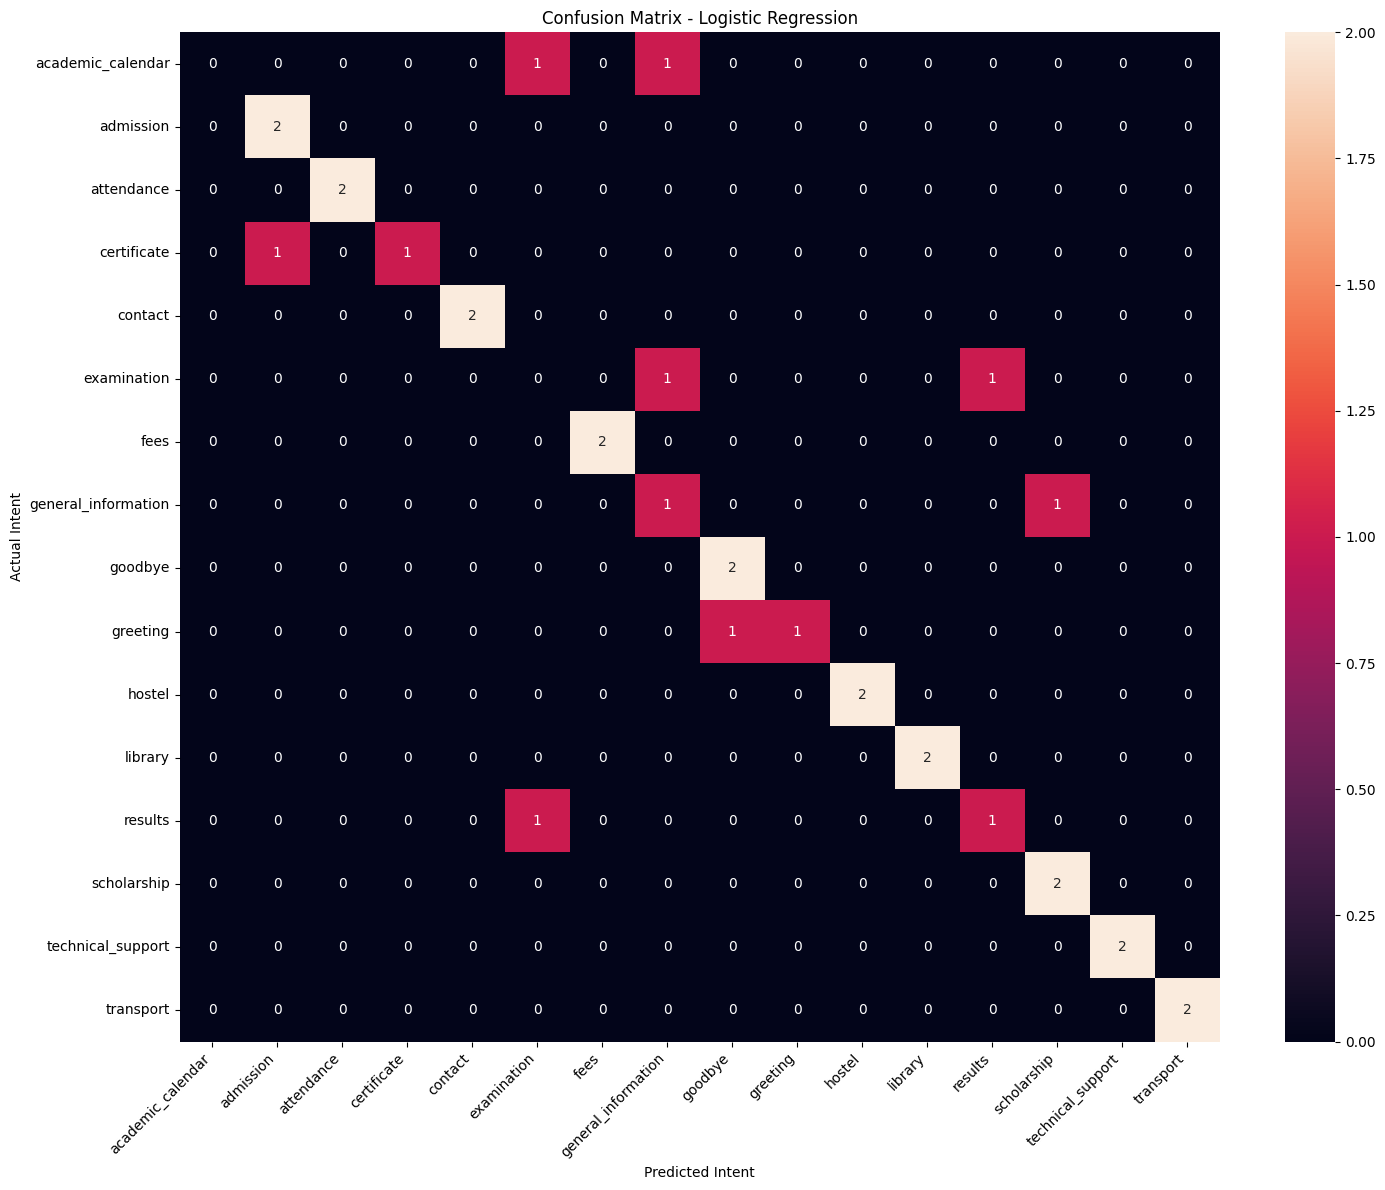

In [26]:
# ============================================
# CELL 20: CONFUSION MATRIX
# ============================================

labels = sorted(df["intent"].unique())

cm = confusion_matrix(
    y_test,
    best_predictions,
    labels=labels
)

plt.figure(figsize=(15, 12))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)

plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.xlabel("Predicted Intent")
plt.ylabel("Actual Intent")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

What is the confusion matrix?

It shows where the model is correctly classifying questions and where it is confusing one intent with another.

For example:

Actual: fees

Predicted: fees

is correct.

But:

Actual: fees

Predicted: scholarship

is a classification error.

## **21 — Create Chatbot Responses**

Now we connect the ML model to actual chatbot responses.

In [27]:
# ============================================
# CELL 21: CHATBOT RESPONSE DATABASE
# ============================================

responses = {

    "greeting": [
        "Hello! Welcome to the Student Support Chatbot. How can I help you?",
        "Hi! I am here to help you with student support services.",
        "Hello! Please ask me your student-related question."
    ],

    "admission": [
        "For admission information, please contact the college admission office or visit the official admission portal.",
        "You can obtain admission forms and document requirements from the college admission office.",
        "The admission process generally includes application, document verification and fee payment."
    ],

    "fees": [
        "You can pay your college fees through the official student fee portal or college accounts office.",
        "For fee payment and receipts, please contact the accounts department.",
        "Please check the official student portal for the latest fee payment deadlines."
    ],

    "scholarship": [
        "Scholarship eligibility depends on the scholarship scheme and student criteria.",
        "Please contact the scholarship or student welfare office for current scholarship opportunities.",
        "You may need academic records and supporting documents when applying for a scholarship."
    ],

    "examination": [
        "The examination timetable is normally published through the official student portal.",
        "Please check the examination section of the college website for the latest schedule.",
        "For examination-related questions, contact the examination department."
    ],

    "results": [
        "Results are normally published through the official student portal.",
        "Please check the result section of the student portal.",
        "If your result is missing, please contact the examination department."
    ],

    "library": [
        "The library provides books, study resources and other academic services.",
        "For current library timings, please check the college library notice or contact the librarian.",
        "Please contact the library desk for book issue, return and renewal information."
    ],

    "hostel": [
        "Hostel admission is generally handled by the hostel or student welfare office.",
        "Please contact the hostel administration for room availability and current fees.",
        "Hostel registration normally requires student identification and supporting documents."
    ],

    "transport": [
        "College transportation information is usually available through the transport office.",
        "Please contact the transport department for current bus routes and timings.",
        "For bus passes and transport fees, contact the college transport office."
    ],

    "academic_calendar": [
        "The academic calendar contains semester dates, holidays and important academic events.",
        "Please check the official college website or student portal for the latest academic calendar.",
        "The academic section can provide information about semester start and end dates."
    ],

    "certificate": [
        "Certificate requests are normally handled by the administration or student section.",
        "Please contact the student section to request a bonafide or other certificate.",
        "You may need your student ID and an application form when requesting a certificate."
    ],

    "attendance": [
        "Attendance information is generally available through the student portal.",
        "Please contact your department if your attendance record appears incorrect.",
        "The minimum attendance requirement depends on the institution and applicable academic rules."
    ],

    "technical_support": [
        "For student portal problems, first try resetting your password.",
        "If you cannot access the portal, please contact the college technical support team.",
        "Please contact the IT support department if your student account is locked."
    ],

    "contact": [
        "Please contact the college administration or student support office for assistance.",
        "The official college website normally contains current department contact details.",
        "For specific academic issues, your department office can direct you to the appropriate person."
    ],

    "general_information": [
        "The Student Support Centre can help students with academic, administrative and campus-related questions.",
        "Student services may include admissions, examinations, fees, library, hostel, scholarships and certificates.",
        "Please tell me what type of student service you need."
    ],

    "goodbye": [
        "Goodbye! Best wishes for your studies.",
        "Thank you for using the Student Support Chatbot. Goodbye!",
        "Goodbye! Have a great day."
    ]
}

print("Response database created successfully!")
print("Number of response categories:", len(responses))

Response database created successfully!
Number of response categories: 16


## **22 — Create the Prediction Function**

In [28]:
# ============================================
# CELL 22: INTENT PREDICTION FUNCTION
# ============================================

def predict_intent(user_input):

    # Clean the user's question
    cleaned_input = clean_text(user_input)

    # Convert text into TF-IDF features
    input_vector = tfidf.transform([cleaned_input])

    # Predict intent
    predicted_intent = best_model.predict(
        input_vector
    )[0]

    # Get confidence if available
    confidence = None

    if hasattr(best_model, "predict_proba"):
        probabilities = best_model.predict_proba(
            input_vector
        )[0]

        confidence = np.max(probabilities)

    return predicted_intent, confidence

## **23 — Create the Chatbot Function**

In [29]:
# ============================================
# CELL 23: CHATBOT FUNCTION
# ============================================

def chatbot_response(user_input, threshold=0.35):

    # Handle empty input
    if not user_input.strip():
        return "Please enter a question."

    # Predict intent
    intent, confidence = predict_intent(user_input)

    # Confidence-based fallback
    if confidence is not None and confidence < threshold:
        return (
            "I'm sorry, I couldn't confidently understand your question. "
            "Please try asking in another way or contact the appropriate "
            "college support department."
        )

    # Select response
    response = random.choice(
        responses[intent]
    )

    return response

## **24 — Test Individual Questions**

In [30]:
# ============================================
# CELL 24: TEST CHATBOT
# ============================================

test_questions = [
    "How can I pay my semester fees?",
    "Where can I find the exam timetable?",
    "How do I apply for scholarship?",
    "What are the library timings?",
    "I forgot my student portal password",
    "How can I apply for hostel?",
    "When will my results come?",
    "Where can I get a bonafide certificate?"
]

for question in test_questions:

    intent, confidence = predict_intent(question)

    print("=" * 70)
    print("Student:", question)
    print("Predicted Intent:", intent)

    if confidence is not None:
        print(
            "Confidence:",
            round(confidence * 100, 2),
            "%"
        )

    print("Chatbot:", chatbot_response(question))

Student: How can I pay my semester fees?
Predicted Intent: fees
Confidence: 22.12 %
Chatbot: I'm sorry, I couldn't confidently understand your question. Please try asking in another way or contact the appropriate college support department.
Student: Where can I find the exam timetable?
Predicted Intent: examination
Confidence: 23.77 %
Chatbot: I'm sorry, I couldn't confidently understand your question. Please try asking in another way or contact the appropriate college support department.
Student: How do I apply for scholarship?
Predicted Intent: scholarship
Confidence: 14.09 %
Chatbot: I'm sorry, I couldn't confidently understand your question. Please try asking in another way or contact the appropriate college support department.
Student: What are the library timings?
Predicted Intent: library
Confidence: 19.95 %
Chatbot: I'm sorry, I couldn't confidently understand your question. Please try asking in another way or contact the appropriate college support department.
Student: I forgo

## **25 — Show Prediction Confidence**

In [32]:
# ============================================
# CELL 25: CONFIDENCE TESTING
# ============================================

questions = [
    "How can I pay my fees?",
    "Tell me library timings",
    "I need a scholarship",
    "Where are my results?",
    "I cannot login"
]

for question in questions:

    intent, confidence = predict_intent(question)

    print(f"Question: {question}")
    print(f"Intent: {intent}")

    if confidence is not None:
        print(
            f"Confidence: {confidence:.2%}"
        )

    print("-" * 60)

Question: How can I pay my fees?
Intent: fees
Confidence: 22.79%
------------------------------------------------------------
Question: Tell me library timings
Intent: library
Confidence: 15.97%
------------------------------------------------------------
Question: I need a scholarship
Intent: scholarship
Confidence: 15.21%
------------------------------------------------------------
Question: Where are my results?
Intent: results
Confidence: 19.90%
------------------------------------------------------------
Question: I cannot login
Intent: technical_support
Confidence: 12.39%
------------------------------------------------------------


## **26 — Interactive Chatbot**
This is the main demonstration.

In [33]:
# ============================================
# CELL 26: INTERACTIVE CHATBOT
# ============================================

print("=" * 70)
print("       AI STUDENT SUPPORT CHATBOT")
print("=" * 70)

print("Type your question below.")
print("Type 'bye' or 'exit' to end the conversation.")
print("=" * 70)

while True:

    user_input = input("You: ")

    if user_input.lower().strip() in [
        "bye",
        "goodbye",
        "exit",
        "quit"
    ]:

        print(
            "Bot:",
            random.choice(responses["goodbye"])
        )

        break

    response = chatbot_response(user_input)

    print("Bot:", response)

       AI STUDENT SUPPORT CHATBOT
Type your question below.
Type 'bye' or 'exit' to end the conversation.
You: bye
Bot: Goodbye! Best wishes for your studies.


# Example
You can type:

You: How do I pay my fees?

The chatbot may answer:

Bot: You can pay your college fees through the official
student fee portal or college accounts office.

Then:

You: Where is the library?

The chatbot identifies:

library

and provides a library-related answer.

## **27 — Save the Model**

Now we save the trained ML components

In [34]:
# ============================================
# CELL 27: SAVE TRAINED MODEL
# ============================================

model_package = {
    "model": best_model,
    "vectorizer": tfidf,
    "responses": responses,
    "intents": sorted(df["intent"].unique()),
    "model_name": best_model_name
}

with open(
    "student_support_chatbot.pkl",
    "wb"
) as file:

    pickle.dump(
        model_package,
        file
    )

print(
    "Model saved successfully as "
    "'student_support_chatbot.pkl'"
)

Model saved successfully as 'student_support_chatbot.pkl'


## **28 — Check Saved File**

In [35]:
# ============================================
# CELL 28: CHECK SAVED MODEL
# ============================================

if os.path.exists(
    "student_support_chatbot.pkl"
):

    file_size = os.path.getsize(
        "student_support_chatbot.pkl"
    )

    print("Model file exists.")
    print(
        "File size:",
        round(file_size / 1024, 2),
        "KB"
    )

else:

    print("Model file not found.")

Model file exists.
File size: 67.77 KB


## **29 — Load the Saved Model**

This proves that your model can be reused later without retraining.

In [36]:
# ============================================
# CELL 29: LOAD SAVED MODEL
# ============================================

with open(
    "student_support_chatbot.pkl",
    "rb"
) as file:

    loaded_package = pickle.load(file)

loaded_model = loaded_package["model"]
loaded_vectorizer = loaded_package["vectorizer"]
loaded_responses = loaded_package["responses"]

print("Saved model loaded successfully!")
print(
    "Model:",
    loaded_package["model_name"]
)

Saved model loaded successfully!
Model: Logistic Regression


## **30 — Test Loaded Model**

In [38]:
# ============================================
# CELL 30: TEST LOADED MODEL
# ============================================

def loaded_chatbot(question):

    cleaned_question = clean_text(question)

    vector = loaded_vectorizer.transform(
        [cleaned_question]
    )

    intent = loaded_model.predict(
        vector
    )[0]

    response = random.choice(
        loaded_responses[intent]
    )

    return intent, response


test = "How do I apply for a scholarship?"

intent, response = loaded_chatbot(test)

print("Student:", test)
print("Intent:", intent)
print("Bot:", response)

Student: How do I apply for a scholarship?
Intent: scholarship
Bot: You may need academic records and supporting documents when applying for a scholarship.


## **31 — 🤖Final Chatbot After Loading**

In [40]:
# ============================================
# CELL 31: FINAL CHATBOT
# ============================================

def final_chatbot():

    print("=" * 70)
    print("        STUDENT SUPPORT AI CHATBOT")
    print("=" * 70)

    print("Ask me about:")
    print("- Admissions")
    print("- Fees")
    print("- Scholarships")
    print("- Examinations")
    print("- Results")
    print("- Library")
    print("- Hostel")
    print("- Transportation")
    print("- Academic Calendar")
    print("- Certificates")
    print("- Attendance")
    print("- Technical Support")
    print("- Contact Information")

    print("\nType 'exit' to stop.")
    print("=" * 70)

    while True:

        question = input("\nStudent: ")

        if question.lower().strip() in [
            "exit",
            "quit",
            "bye"
        ]:

            print(
                "Bot:",
                random.choice(
                    loaded_responses["goodbye"]
                )
            )

            break

        if not question.strip():

            print(
                "Bot: Please enter a question."
            )

            continue

        intent, response = loaded_chatbot(
            question
        )

        print("Bot:", response)


# Run chatbot
final_chatbot()

        STUDENT SUPPORT AI CHATBOT
Ask me about:
- Admissions
- Fees
- Scholarships
- Examinations
- Results
- Library
- Hostel
- Transportation
- Academic Calendar
- Certificates
- Attendance
- Technical Support
- Contact Information

Type 'exit' to stop.

Student: Technical Support
Bot: For student portal problems, first try resetting your password.

Student: Academic Calendar
Bot: The academic section can provide information about semester start and end dates.

Student: exit
Bot: Goodbye! Have a great day.


# ❌**Limitations**



*   Works mainly with predefined intents

*   Cannot reliably answer completely unrelated questions.

*   Responses depend on the quality of the training dataset.

*   Does not currently access real-time student records.

*  Generic responses need to be replaced with institution-specific information.





#🚀 **Future Scope**

*  Integrate with a college database.
*   Add multilingual support.
*   Add voice-based interaction.
*   Develop a web/mobile interface
*   Provide personalized student information after authentication



#💬**Project Summary**

## Project Title
**AI Chatbot for Student Support Services**

##💻 Technologies Used

- Python
- Google Colab
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Natural Language Processing
- TF-IDF
- Logistic Regression
- Naive Bayes
- Random Forest

##⚙️ Machine Learning Workflow

The project follows these steps:

1. Dataset creation
2. Data cleaning
3. Exploratory Data Analysis
4. Text preprocessing
5. TF-IDF feature extraction
6. Train-test split
7. Machine learning model training
8. Model comparison
9. Model evaluation
10. Best model selection
11. Chatbot development
12. Confidence-based response handling
13. Model saving
14. Model loading
15. Final chatbot testing

###📋 **Result**

The final system can classify student questions into
different support categories and provide an appropriate
response.

The system can be expanded by adding more student questions,
new intents and institution-specific information.

# 📌**Conclusion**


*   The project demonstrates the practical use of AI, NLP, and Machine Learning in student-support services.
*   The chatbot can automatically understand and classify common student queries.
*   It provides a simple, efficient, and scalable solution for first-level student assistance.
* With institutional data and advanced AI technologies, the system can be developed into a comprehensive student-support platform.


